In [99]:
using ModelingToolkitStandardLibrary.Electrical, ModelingToolkit, OrdinaryDiffEq, Test, Plots
using ModelingToolkit: t_nounits as t, D_nounits as D
using ModelingToolkitStandardLibrary.Blocks: Constant, Step, RealInput

In [100]:
@mtkmodel IdealSwitch begin
    @extend v, i = oneport = OnePort()

    @parameters begin
        state_start_on = false
        Gon = 1e5
        τ = 1e-3
    end

    @components begin
        port = RealInput()
    end

    @variables begin
        state(t)::Bool
        state_filtered(t) = Real(state_start_on)
        G(t)
    end

    @equations begin
        state ~ port.u
        D(state_filtered) ~ (state - state_filtered)/τ
        G ~ state_filtered*Gon
        i ~ G*v
    end
end;

In [101]:
@mtkmodel SwitchTest begin
    @parameters begin
        V = 10.0
        C = 1.0
        R = 1.0
    end

    @components begin
        step = Step(start_time=10.0, height=true, smooth=false)
        switch = IdealSwitch()
        voltage = Voltage()
        resistor = Resistor(R=R)
        capacitor = Capacitor(C=C, v=0.0)
        ground = Ground()
        constant = Constant(k=V)
    end

    @equations begin
        connect(voltage.p, switch.p)
        connect(switch.n, resistor.p)
        connect(resistor.n, capacitor.p)
        connect(voltage.n, capacitor.n, ground.g)
        connect(step.output, switch.port)
        connect(constant.output, voltage.V)
    end
end;

In [102]:
@mtkbuild sys = SwitchTest()

println("System Equations:")
for (i, eq) in enumerate(full_equations(sys))
    println("$i. $eq")
end

System Equations:
1. Differential(t)(switch₊state_filtered(t)) ~ (step₊offset + ifelse((step₊start_time <= t) & (t < (step₊duration + step₊start_time)), step₊height, 0) - switch₊state_filtered(t)) / switch₊τ
2. Differential(t)(capacitor₊v(t)) ~ ((constant₊k - capacitor₊v(t) - resistor₊R*resistor₊i(t))*switch₊Gon*switch₊state_filtered(t)) / capacitor₊C
3. 0 ~ resistor₊i(t) + (-constant₊k + capacitor₊v(t) + resistor₊R*resistor₊i(t))*switch₊Gon*switch₊state_filtered(t)


In [103]:
prob = ODEProblem(sys, [], (0.0, 25.0))
sol = solve(prob, Rodas4P());

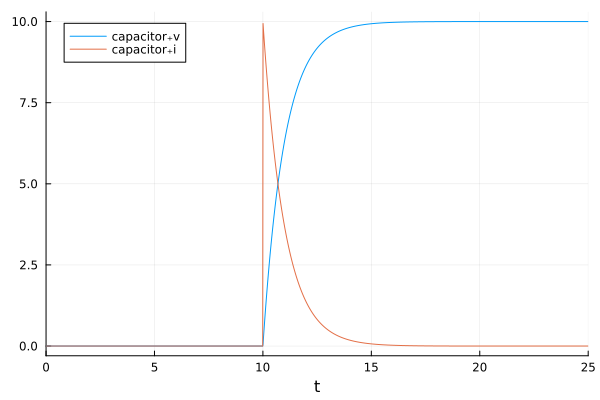

In [104]:
plot(sol; vars = [sys.capacitor.v, sys.capacitor.i])

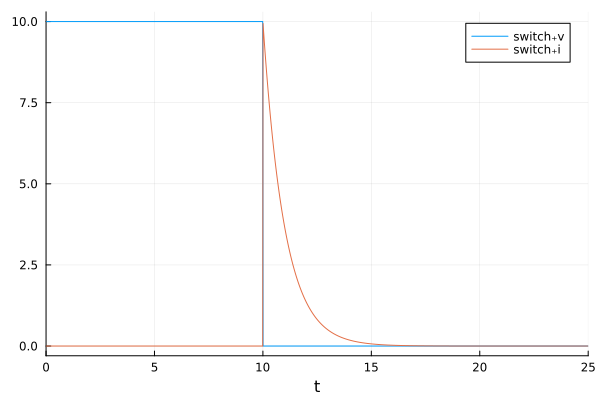

In [105]:
plot(sol; vars = [sys.switch.v, sys.switch.i])